In [1]:
import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt
import torch
from tqdm import tqdm
from torch.nn.functional import pad

In [2]:
from transformers import GPT2LMHeadModel, GPT2TokenizerFast
from transformers import LlamaForCausalLM, LlamaTokenizerFast

import argparse
import pickle
import os
import json
import pandas as pd

model_id = "gpt2"
device = "cuda:1"
perplexity_func = "p1"

if "gpt2" in model_id:
    model = GPT2LMHeadModel.from_pretrained(model_id).to(device)
    tokenizer = GPT2TokenizerFast.from_pretrained(model_id)
    start_of_sentence=" "
print(f"Loaded model: {model_id}")

/u/sebono/miniconda3/lib/python3.9/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Loaded model: gpt2


In [3]:
model_id = "gpt2"
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model : GPT2LMHeadModel = GPT2LMHeadModel.from_pretrained(model_id).to(device)
tokenizer : GPT2TokenizerFast = GPT2TokenizerFast.from_pretrained(model_id)

In [4]:
import pandas as pd
import re
import numpy as np

candor_df = pd.read_csv("/u/sebono/conversational_dominance/data/processed/CANDOR_gpt2-large/conversations.csv")
candor_df.head()

,file_name,file_content
0,7595d874-c1cb-4aef-918f-3c81f3a84324,<SPK0> this is Yeah. Mhm. Mhm. Yeah. Yeah. Mot...
1,66768810-879d-4e2f-b5f5-ecc67d298104,<SPK0> Uh huh uh huh. Yeah. <SPK1> Yeah. All r...
2,dc3d0ae4-8d20-4d1d-8e0c-82c85a79b26e,<SPK1> Yeah. Right. Mhm. Mhm. Mhm. Okay. Yeah....
3,fb50ccf7-1a5a-4d80-b4f0-d5d1a1fd1135,<SPK0> Hi there and move away. <SPK1> mm. <SPK...
4,73c201ef-8c32-43d4-b642-dcedf4aa5c7f,<SPK0> Yeah. Okay. Yeah. Mhm. Yeah. Mhm Uh huh...


In [5]:
name_file = candor_df.iloc[0]["file_name"]
conversation = candor_df.iloc[0]["file_content"]

In [6]:
import re 
pattern = r'<(?:SPK[0-9]|MOD)>'
dialog_lines = conversation.replace(" <", "\n<").split("\n")[1:]
start_of_sentence=" "
matches = re.findall(pattern, "".join(dialog_lines))
token_list = [tokenizer(token, return_tensors="pt").input_ids[0] for token in dialog_lines]
encodings = tokenizer(f"{start_of_sentence}".join(dialog_lines), return_tensors="pt")

Token indices sequence length is longer than the specified maximum sequence length for this model (11410 > 1024). Running this sequence through the model will result in indexing errors


In [7]:
all_data = pd.read_csv(f"../information_exchange_labelling/{candor_df.iloc[0]['file_name']}_candor_ppl.csv")

In [8]:
assert len(all_data['baselined_p1_scores']) == len(encodings.input_ids[0])

In [9]:
def compute_dominance_per_spk(perplexity, token_list, matches, tokenizer):
    prev_idx_pp = 0
    tokens_ids_per_sentence = np.cumsum([t.size(0) for t in token_list])
    dialog = [tokenizer.decode(token, skip_special_tokens=True) for token in token_list]
    all_values = []
    ppls_p_spk={}
    for idx, match in enumerate(matches):
        if match not in ppls_p_spk:
            ppls_p_spk[match] = []
        for px in range(len(token_list[idx])):
            fin_idx = px + np.sum([len(l) for l in token_list[:idx]], dtype=int)
            ppls_p_spk[match].append(perplexity[fin_idx])
    return ppls_p_spk

In [10]:
# Run statistical tests
from scipy import stats
def compute_significance(original_ppls_p_spk):
    spk1_clean = np.array(original_ppls_p_spk["<SPK0>"])
    spk2_clean = np.array(original_ppls_p_spk["<SPK1>"])

    ppl_spk1 = spk1_clean[~np.isnan(spk1_clean)]
    ppl_spk2 = spk2_clean[~np.isnan(spk2_clean)]

    ks_stat, ks_pvalue = stats.ks_2samp(ppl_spk1, ppl_spk2)
    mw_stat, mw_pvalue = stats.mannwhitneyu(ppl_spk1, ppl_spk2, alternative='two-sided')
    tt_stat, tt_pvalue = stats.ttest_ind(ppl_spk1, ppl_spk2, equal_var=False)

    return {
        "Kolmogorov-Smirnov": {"statistic": ks_stat, "p_value": ks_pvalue},
        "Mann-Whitney U": {"statistic": mw_stat, "p_value": mw_pvalue},
        "T-test": {"statistic": tt_stat, "p_value": tt_pvalue}
    }

In [11]:
import os
os.chdir("/u/sebono/conversational_dominance/information_exchange_labelling")
os.getcwd()

'/u/sebono/conversational_dominance/information_exchange_labelling'

In [13]:
from utils import correlation_heatmap, compute_dominance_per_spk, rolling_kde_heatmap_with_turns, remove_match_prefix_ppl, compute_graph_perplexity, display_turns_colored_by_kde

In [14]:
baselined_ppls_p1_spk = compute_dominance_per_spk(all_data["baselined_p1_scores"], token_list, matches, tokenizer)
baselined_ppls_p2_spk = compute_dominance_per_spk(all_data["baselined_p2_scores"], token_list, matches, tokenizer)
baselined_ppls_p3_spk = compute_dominance_per_spk(all_data["baselined_p3_scores"], token_list, matches, tokenizer)

In [15]:
from transformers import AutoTokenizer
import numpy as np

def remove_match_prefix_ppl(token_list, ppl, matches, tokenizer, min_len=3):
    """
    Removes matching prefixes from each line and filters out entire turns if remaining token length is below threshold.

    Args:
        token_list (List[List[int]]): Tokenized dialog lines.
        ppl (List[float]): Flat list of token-level PPL values.
        matches (List[str]): List of string prefixes to remove from each line.
        tokenizer: HuggingFace tokenizer used.
        min_len (int): Minimum length (after prefix removal) to keep the turn.

    Returns:
        Tuple[
            List[List[int]],  # filtered_tokens
            List[float],      # filtered_ppl
            List[int],        # flat_token_ids
            List[str]         # filtered_matches
        ]
    """
    assert len(token_list) == len(matches), "Mismatch between token list and matches"

    line_offsets = np.cumsum([0] + [len(t) for t in token_list[:-1]])  # start index in flat PPL array

    filtered_tokens = []
    filtered_ppl = []
    flat_token_ids = []
    filtered_matches = []

    for i, (token, match) in enumerate(zip(token_list, matches)):
        tok_match = tokenizer(match, return_tensors="pt")
        match_tok_len = len(tok_match.input_ids[0])

        # Slice off the match prefix
        token_filtered = token[match_tok_len:]

        if len(token_filtered) < min_len:
            continue  # skip turn entirely if below threshold

        # Keep this turn
        filtered_tokens.append(token_filtered)
        filtered_matches.append(match)

        # Extract aligned PPL values
        start = line_offsets[i] + match_tok_len
        end = line_offsets[i] + len(token)
        turn_ppl = ppl[start:end]

        assert len(turn_ppl) == len(token_filtered), f"PPL/token mismatch at turn {i}"
        
        filtered_ppl.extend(turn_ppl)
        flat_token_ids.extend(token_filtered)

    return filtered_tokens, filtered_ppl, flat_token_ids, filtered_matches

In [16]:
filtered_tokens_p1, filtered_ppl_p1, filtered_encodings_p1, filtered_matches_p1 = remove_match_prefix_ppl(token_list, all_data['original_dialog_p1'], matches, tokenizer)
assert np.cumsum([len(token) for token in filtered_tokens_p1])[-1], len(filtered_ppl)

In [17]:
filtered_tokens_p2, filtered_ppl_p2, filtered_encodings_p2, filtered_matches_p2 = remove_match_prefix_ppl(token_list, all_data['original_dialog_p2'], matches, tokenizer)
assert np.cumsum([len(token) for token in filtered_tokens_p2])[-1], len(filtered_ppl)

In [18]:
filtered_tokens_p3, filtered_ppl_p3, filtered_encodings_p3, filtered_matches_p3 = remove_match_prefix_ppl(token_list, all_data['original_dialog_p3'], matches, tokenizer)
assert np.cumsum([len(token) for token in filtered_tokens_p3])[-1], len(filtered_ppl)

In [19]:
assert len(filtered_encodings_p1) == len(filtered_encodings_p3)
assert len(filtered_encodings_p1) == len(filtered_encodings_p2)
filtered_encodings = filtered_encodings_p1

In [20]:
import numpy as np

def compute_turn_to_token_positions(intervals, token_list_per_turn):
    """
    For a list of (start_turn, end_turn) intervals, compute the corresponding token indices.

    Args:
        intervals (List[Tuple[int, int]]): List of (start_turn, end_turn) indices (1-based inclusive start, exclusive end).
        token_list_per_turn (List[List[int]]): List of tokenized turns.

    Returns:
        List[Tuple[int, int]]: List of (start_token_idx, end_token_idx) for each interval.
    """
    cum_lengths = np.cumsum([len(t) for t in token_list_per_turn])
    token_ranges = []

    for start_turn, end_turn in intervals:
        assert start_turn < end_turn, f"Invalid interval: ({start_turn}, {end_turn})"

        turn_cum_sum_start = cum_lengths[start_turn - 1] if start_turn > 0 else 0
        turn_cum_sum_end = cum_lengths[end_turn - 1]
        len_ppl_turn = sum(len(t) for t in token_list_per_turn[start_turn:end_turn])

        assert (turn_cum_sum_end - turn_cum_sum_start) == len_ppl_turn, \
            f"Mismatch in expected length for interval ({start_turn}, {end_turn})"

        token_ranges.append((turn_cum_sum_start, turn_cum_sum_end))

    return token_ranges

In [21]:
def extract_tokens_and_ppls_by_turn_indices(turn_indices, token_list, ppls):
    """
    Extracts a filtered list of token lists and aligned PPLs from a flat PPL array.

    Args:
        turn_indices (List[int]): Indices of turns to keep.
        token_list (List[List[int]]): Full list of token lists.
        ppls (List[float]): Flattened list of per-token PPLs.

    Returns:
        Tuple:
            filtered_token_list (List[List[int]]): Subset of token_list
            filtered_ppl (List[float]): Subset of PPL values aligned with token IDs
    """
    token_lengths = [len(t) for t in token_list]
    cum_starts = np.cumsum([0] + token_lengths)

    filtered_token_list = []
    filtered_ppl = []

    for idx in turn_indices:
        start = cum_starts[idx]
        end = cum_starts[idx + 1]
        filtered_token_list.append(token_list[idx])
        filtered_ppl.extend(ppls[start:end])

    return filtered_token_list, filtered_ppl


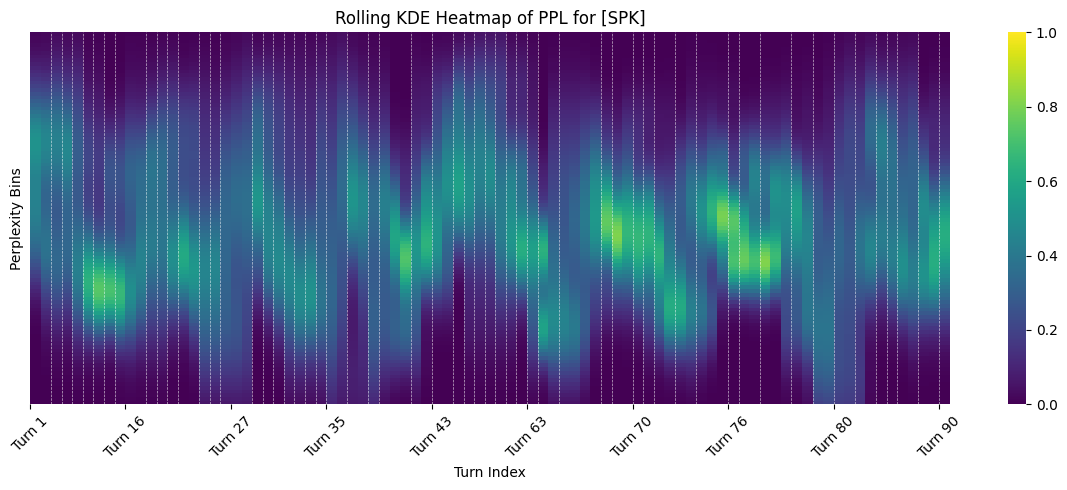

In [60]:
# Get turn indices for SPK1
start_turn=332
end_turn=-1
idx_spk0 = start_turn + np.where(np.asarray(filtered_matches_p3)[start_turn:end_turn] == '<SPK0>')[0]

# Get filtered tokens and PPLs
filtered_tokens_p2_spk0, filtered_ppl_p2_spk0 = extract_tokens_and_ppls_by_turn_indices(
    idx_spk0, filtered_tokens_p2, filtered_ppl_p2
)
den = rolling_kde_heatmap_with_turns(token_list=filtered_tokens_p2_spk0, ppls=filtered_ppl_p2_spk0,window_size=50, vmin=0, vmax=1.0)

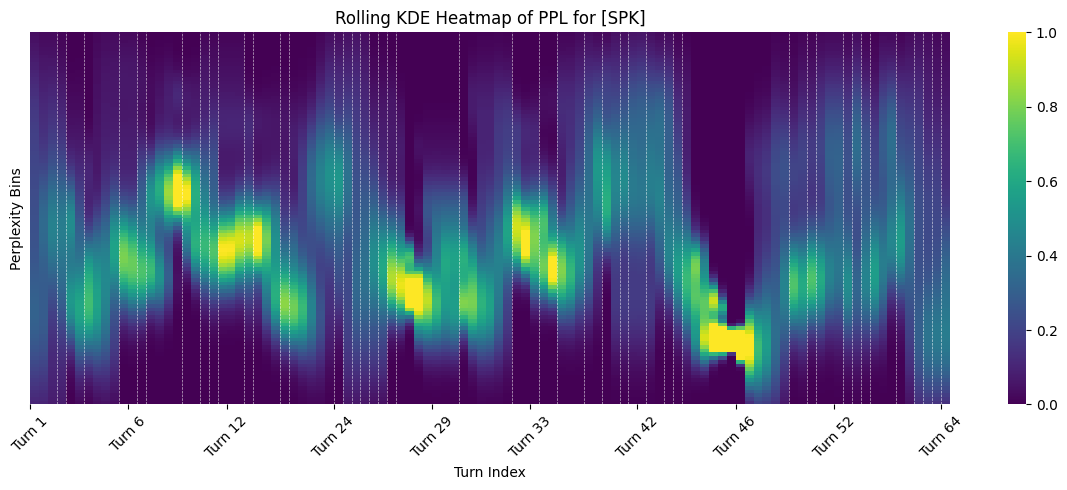

In [59]:
# Get turn indices for SPK1
start_turn=332
end_turn=-1
idx_spk1 = start_turn + np.where(np.asarray(filtered_matches_p3)[start_turn:end_turn] == '<SPK1>')[0]

# Get filtered tokens and PPLs
filtered_tokens_p2_spk1, filtered_ppl_p2_spk1 = extract_tokens_and_ppls_by_turn_indices(
    idx_spk1, filtered_tokens_p2, filtered_ppl_p2
)
den = rolling_kde_heatmap_with_turns(token_list=filtered_tokens_p2_spk1, ppls=filtered_ppl_p2_spk1,window_size=50, vmin=0, vmax=1.0)

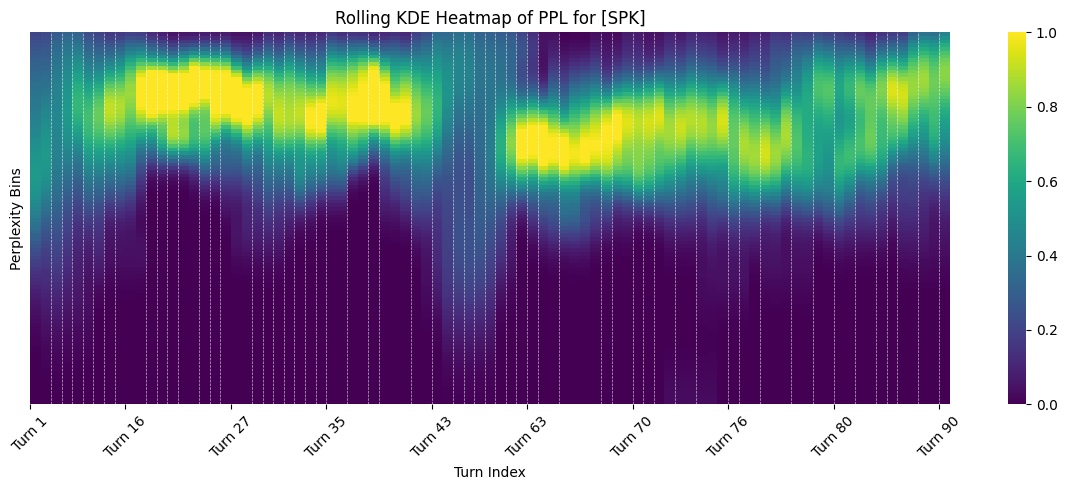

In [61]:
# Get turn indices for spk0
start_turn=332
end_turn=-1
idx_spk0 = start_turn + np.where(np.asarray(filtered_matches_p3)[start_turn:end_turn] == '<SPK0>')[0]

# Get filtered tokens and PPLs
filtered_tokens_p3_spk0, filtered_ppl_p3_spk0 = extract_tokens_and_ppls_by_turn_indices(
    idx_spk0, filtered_tokens_p3, filtered_ppl_p3
)
den = rolling_kde_heatmap_with_turns(token_list=filtered_tokens_p3_spk0, ppls=filtered_ppl_p3_spk0, window_size=50, vmin=0, vmax=1.0)

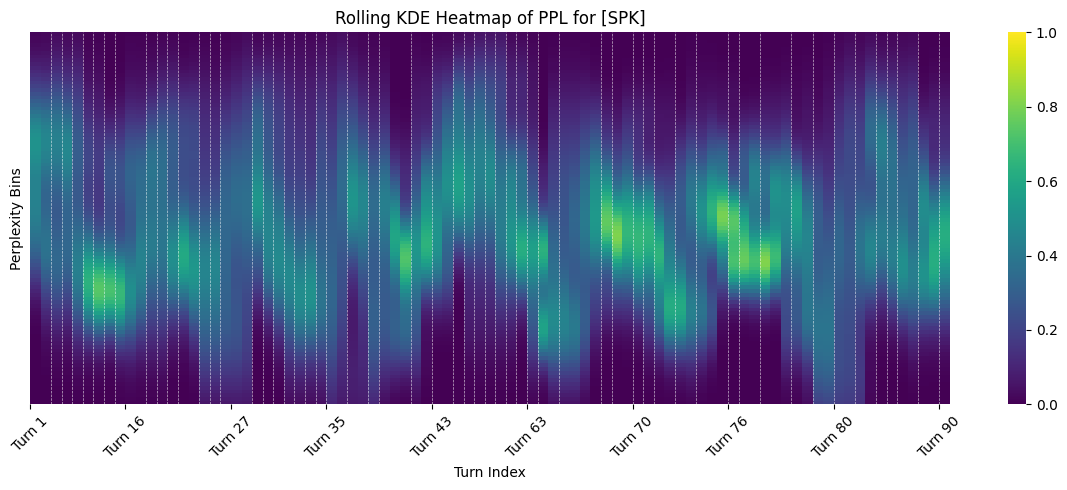

In [65]:
# Get turn indices for spk0
start_turn=332
end_turn=-1
idx_spk0 = start_turn + np.where(np.asarray(filtered_matches_p2)[start_turn:end_turn] == '<SPK0>')[0]

# Get filtered tokens and PPLs
filtered_tokens_p2_spk0, filtered_ppl_p2_spk0 = extract_tokens_and_ppls_by_turn_indices(
    idx_spk0, filtered_tokens_p2, filtered_ppl_p2
)
den = rolling_kde_heatmap_with_turns(token_list=filtered_tokens_p2_spk0, ppls=filtered_ppl_p2_spk0, window_size=50, vmin=0, vmax=1.0)

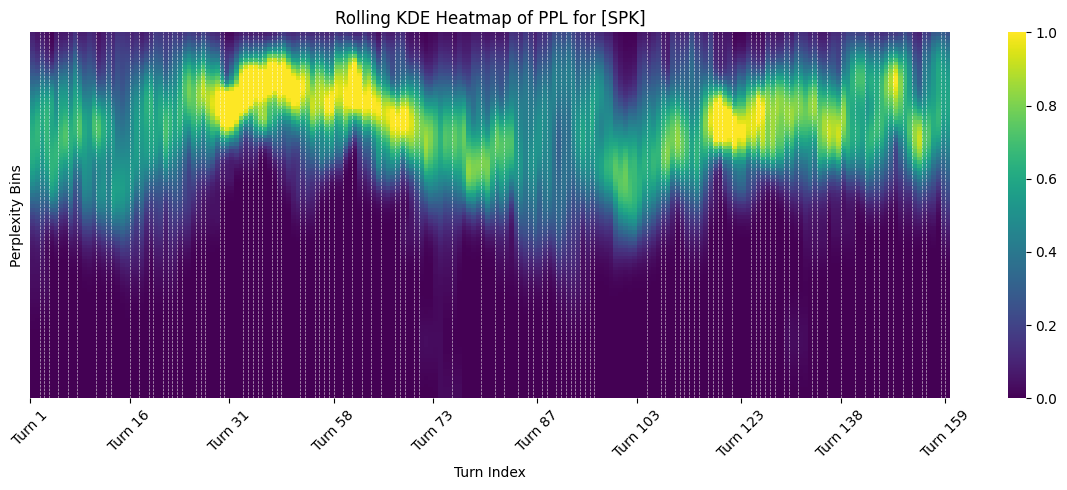

In [66]:
# Get turn indices for spks
start_turn=332
end_turn=-1
idx_spks = start_turn + np.where(np.asarray(filtered_matches_p3)[start_turn:end_turn] != "")[0]

# Get filtered tokens and PPLs
filtered_tokens_p3_spks, filtered_ppl_p3_spks = extract_tokens_and_ppls_by_turn_indices(
    idx_spks, filtered_tokens_p3, filtered_ppl_p3
)
den = rolling_kde_heatmap_with_turns(token_list=filtered_tokens_p3_spks, ppls=filtered_ppl_p3_spks, window_size=50, vmin=0, vmax=1.0)

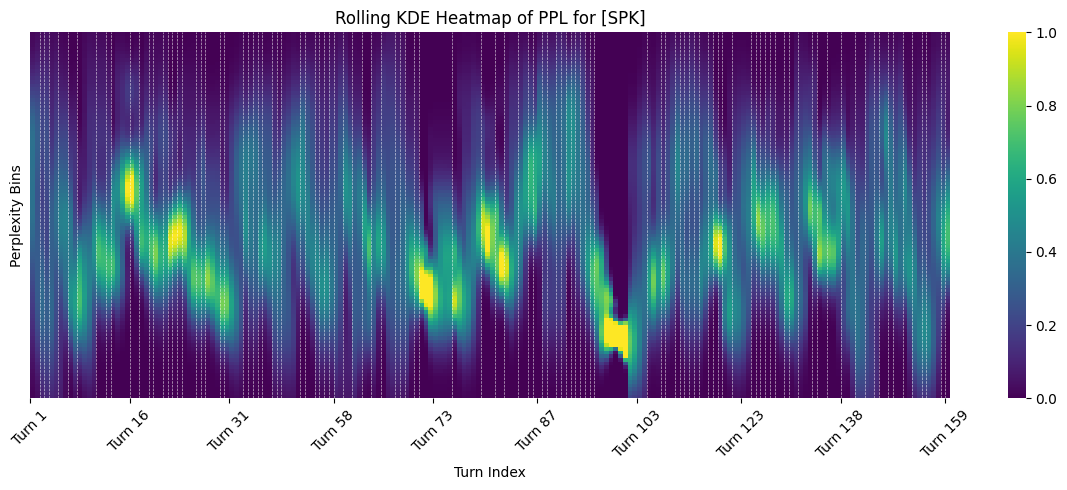

In [67]:
# Get turn indices for spks
start_turn=332
end_turn=-1
idx_spks = start_turn + np.where(np.asarray(filtered_matches_p2)[start_turn:end_turn] != "")[0]

# Get filtered tokens and PPLs
filtered_tokens_p2_spks, filtered_ppl_p2_spks = extract_tokens_and_ppls_by_turn_indices(
    idx_spks, filtered_tokens_p2, filtered_ppl_p2
)
den = rolling_kde_heatmap_with_turns(token_list=filtered_tokens_p2_spks, ppls=filtered_ppl_p2_spks, window_size=50, vmin=0, vmax=1.0)

In [27]:
[(idx, match, tokenizer.decode(token, skip_special_tokens=True)) for idx, (token, match) in enumerate(zip(filtered_tokens_p3[start_turn:end_turn], filtered_matches_p3[start_turn:end_turn]))]

[(0, '<SPK0>', " I've actually never been to that area. Um I would like"),
 (1, '<SPK0>', ' to go to the Chicago area but probably like in the spring,'),
 (2, '<SPK0>', ' you know, not'),
 (3, '<SPK0>', " when it's super cold."),
 (4,
  '<SPK1>',
  " Mhm. Yeah, Chicago um is really fun um I mean obviously you know it's a huge city"),
 (5,
  '<SPK1>',
  ' but uh downtown area really nice parks and do um obviously dining and shopping'),
 (6,
  '<SPK1>',
  " and all that, but my girlfriend, she lives in the city and she's telling me she's like getting depressed because"),
 (7, '<SPK0>', ' Mhm.'),
 (8,
  '<SPK1>',
  " in addition to the virus um there's been so much protesting and writing and things of that nature and she said like even in her neighborhood which had been pretty much crime free um crime has spiked."),
 (9,
  '<SPK1>',
  ' Oh great. Yeah, which I mean you know a lot of people are out of work'),
 (10, '<SPK1>', ' and that seems to like naturally follow you know that'),
 (11, 

In [71]:
import matplotlib.pyplot as plt
from IPython.display import display, HTML
import matplotlib.colors as mcolors

def display_colored_sentences(tokens_list, p1, bound = None):
    encodings = torch.cat(tokens_list)
    decoded_tokens = [tokenizer.decode([token], skip_special_tokens=False) for token in encodings]

    tokens_ids_per_sentence = np.cumsum([t.size(0) for t in tokens_list])
    assert tokens_ids_per_sentence[-1] == len(p1)

    global_min = np.nanmin(p1)
    global_max = np.nanmax(p1)
    if bound != None:
        global_min, global_max = bound

    # Create a white-to-red colormap
    cmap = plt.cm.Reds
    cmap = cmap(np.linspace(0, 1, 256))
    # cmap[:50, :] = 1  # make the first 50 entries white (RGBA=1,1,1,1)
    white_to_red = mcolors.ListedColormap(cmap)

    html_output = ""
    prev_idx_pp = 0

    for idx in range(len(tokens_list)):
        idx_pp = tokens_ids_per_sentence[idx]
        sentence_tokens = decoded_tokens[prev_idx_pp:idx_pp]
        sentence_p1 = p1[prev_idx_pp:idx_pp]

        colored_sentence = ""
        for token, score in zip(sentence_tokens, sentence_p1):
            token = token.strip()
            token = token.replace("<", "&lt;").replace(">", "&gt;")

            if global_max == global_min:
                norm_score = 0.0
            else:
                norm_score = (score - global_min) / (global_max - global_min)
            r, g, b, _ = white_to_red(norm_score)
            color = mcolors.to_hex((r, g, b))
            colored_sentence += f'<span style="color:{color}">{str(token)}</span> '
        html_output += f"<span style='line-height:1.8em; font-size:130%; font-weight: bolder;'>{colored_sentence}</span><br>"
        prev_idx_pp = idx_pp

    # Display the HTML sentences
    display(HTML(html_output))

    # Create the color bar
    fig, ax = plt.subplots(figsize=(6, 1))
    norm = plt.Normalize(vmin=global_min, vmax=global_max)
    fig.subplots_adjust(bottom=0.5)

    cb1 = plt.colorbar(
        plt.cm.ScalarMappable(norm=norm, cmap=white_to_red),
        cax=ax, orientation='horizontal'
    )
    cb1.set_label('Perplexity')
    plt.show()

import re

def preprocess(text, pattern=r'<(SPK[1-9]|MOD)>'):
    matches = re.findall(pattern, text)
    dialog = text.replace('\n', '')
    dialog = re.sub(pattern, lambda m: '\n' + m.group(0), dialog)
    dialog_lines = [
        line.strip() + ' '
        for line in dialog.split('\n')
        if line.strip()
    ]

    return dialog_lines, matches


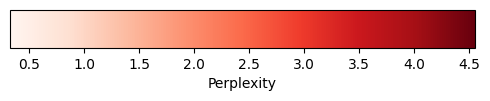

In [72]:
display_colored_sentences(filtered_tokens_p2_spks, filtered_ppl_p2_spks)

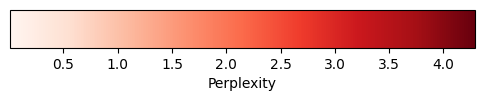

In [73]:
display_colored_sentences(filtered_tokens_p3_spks, filtered_ppl_p3_spks)